# H1: Yield Stability Hypothesis

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
final_df = pd.read_csv("data/final/agri_combined_dataset.csv")
final_df.head()

,state,district,crop,year,area,production,yield,annual_rainfall,n_high,n_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
0,andhra pradesh,alluri sitharama raju,Cotton(lint),2022,2682.0,7614.0,2.84,NaN,3.26,54.11,...,44.99,29.87,27.25,64.48,8.27,0.12,18.93,80.95,99.81,0.19
1,andhra pradesh,anakapalli,Cotton(lint),2022,82.0,230.0,2.80,NaN,12.10,25.02,...,22.88,8.79,12.98,25.62,61.40,0.62,0.10,99.27,98.99,1.01
2,andhra pradesh,anantapur,Cotton(lint),2012,28000.0,35000.0,1.25,536,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
3,andhra pradesh,anantapur,Cotton(lint),2013,37661.0,77316.0,2.05,501.7,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
4,andhra pradesh,anantapur,Cotton(lint),2014,73734.0,103779.0,1.41,437.8,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39


In [86]:
h1_table = (
    final_df
    .groupby(["state","crop"])["yield"]
    .agg(["mean","std"])
)

h1_table["cv"] = h1_table["std"] / h1_table["mean"]

h1_table = h1_table.reset_index()

h1_table.head()

,state,crop,mean,std,cv
0,andhra pradesh,Cotton(lint),2.478750,1.090824,0.440070
1,andhra pradesh,Groundnut,1.859459,1.056631,0.568246
2,andhra pradesh,Maize,4.129554,1.309065,0.316999
3,andhra pradesh,Ragi,1.184667,0.424103,0.357994
4,andhra pradesh,Rice,3.199732,0.629720,0.196804


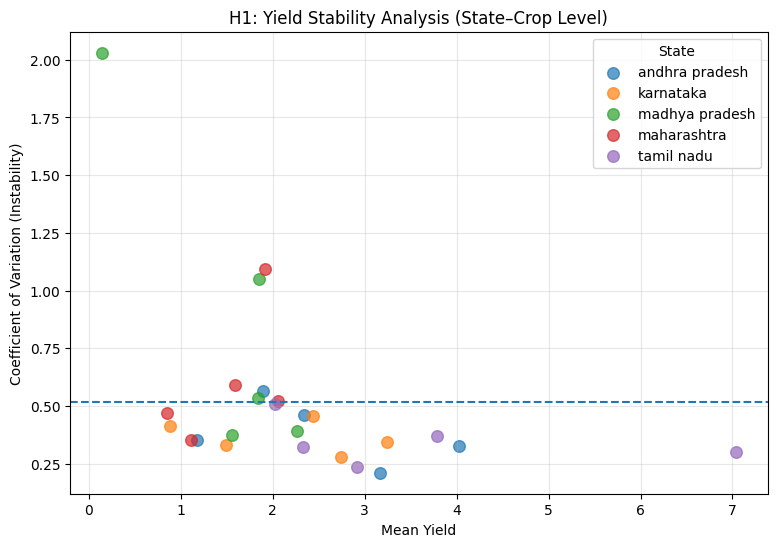

In [ ]:
plt.figure(figsize=(9,6))
for state, group in h1_table.groupby("state"):
    plt.scatter(
        group["mean"],
        group["cv"],
        label=state,
        alpha=0.7,     
        s=70           
    )


plt.axhline(h1_table["cv"].mean(), linestyle="--")

plt.xlabel("Mean Yield")
plt.ylabel("Coefficient of Variation (Instability)")
plt.title("H1: Yield Stability Analysis (State–Crop Level)")

plt.legend(title="State")
plt.grid(alpha=0.3)

plt.savefig("outputs/h1_stability_plot.png", bbox_inches="tight")

plt.show()

# H2: Temporal Robustness Hypothesis

In [67]:
from scipy.stats import ttest_ind

In [68]:
median_year = final_df["year"].median()
median_year

np.float64(2017.0)

In [69]:
splits = [median_year - 1, median_year, median_year + 1]

results = []

for split in splits:

    early = final_df[final_df["year"] <= split]["yield"]
    late  = final_df[final_df["year"] > split]["yield"]

    t_stat, p_value = ttest_ind(early, late, equal_var=False)

    results.append([
        split,
        early.mean(),
        late.mean(),
        p_value
    ])

h2_results = pd.DataFrame(
    results,
    columns=["Split Year","Early Mean","Late Mean","p-value"]
)

h2_results

,Split Year,Early Mean,Late Mean,p-value
0,2016.0,2.228303,2.428120,8.397649e-07
1,2017.0,2.260725,2.427784,5.214319e-05
2,2018.0,2.244909,2.491635,1.193965e-08


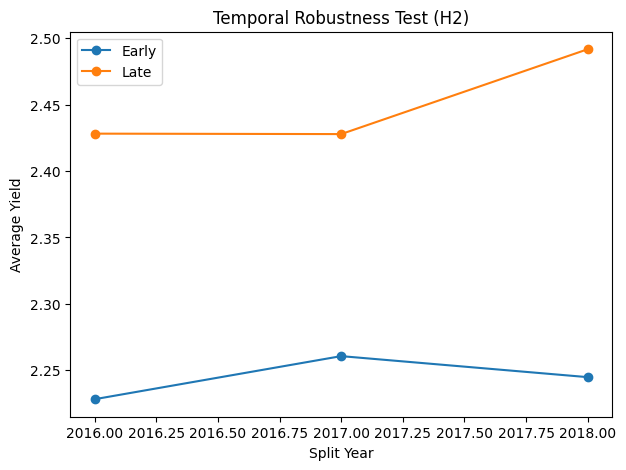

In [70]:
plt.figure(figsize=(7,5))

plt.plot(h2_results["Split Year"], h2_results["Early Mean"], marker='o', label="Early")
plt.plot(h2_results["Split Year"], h2_results["Late Mean"], marker='o', label="Late")

plt.xlabel("Split Year")
plt.ylabel("Average Yield")
plt.title("Temporal Robustness Test (H2)")
plt.legend()
h2_results.to_csv("outputs/h2_temporal_robustness.csv", index=False)

plt.savefig("outputs/h2_temporal_plot.png")
plt.show()

# H3: Rainfall Dependence Hypothesis

In [76]:
final_df.replace("—", pd.NA, inplace=True)

final_df["yield"] = pd.to_numeric(final_df["yield"], errors="coerce")
final_df["annual_rainfall"] = pd.to_numeric(final_df["annual_rainfall"], errors="coerce")

final_df.dropna(subset=["yield","annual_rainfall"], inplace=True)

In [78]:
median_year = final_df["year"].median()

early_df = final_df[final_df["year"] <= median_year]
late_df  = final_df[final_df["year"] > median_year]

In [79]:
overall_corr = final_df[["yield","annual_rainfall"]].corr().loc["yield","annual_rainfall"]

early_corr = early_df[["yield","annual_rainfall"]].corr().loc["yield","annual_rainfall"]

late_corr = late_df[["yield","annual_rainfall"]].corr().loc["yield","annual_rainfall"]

In [ ]:
h3_summary = pd.DataFrame({
    "Period": ["Overall", "Early Years", "Late Years"],
    "Yield-Rainfall Correlation": [
        overall_corr,
        early_corr,
        late_corr
    ]
})

h3_summary

,Period,Yield-Rainfall Correlation
0,Overall,-0.002213
1,Early Years,-0.000884
2,Late Years,-0.018137


In [ ]:
h3_summary.to_csv("outputs/h3_correlation_summary.csv", index=False)

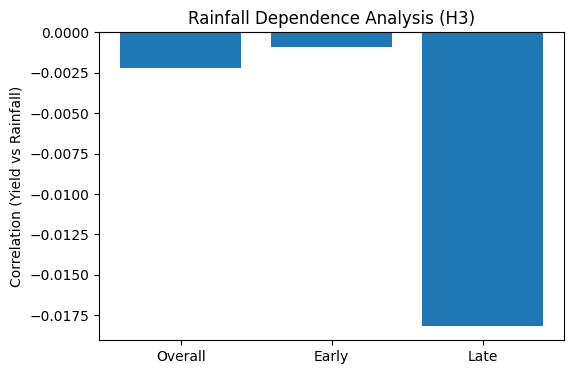

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)
plt.figure(figsize=(6,4))
plt.bar(h3_table["Period"], h3_table["Correlation"])
plt.axhline(y=0, linestyle="--")
plt.ylabel("Correlation (Yield vs Rainfall)")
plt.title("Rainfall Dependence Analysis (H3)")
plt.savefig("outputs/h3_rainfall_plot.png", bbox_inches="tight")
plt.show()

# H4 : Indicator Sufficiency Hypothesis

In [ ]:
mean_rank = (
    final_df.groupby("state")["yield"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

mean_rank.head()

,state,yield
0,tamil nadu,3.611175
1,andhra pradesh,2.568227
2,karnataka,2.175483
3,madhya pradesh,1.885317
4,maharashtra,1.568433


In [ ]:
h4_table = final_df.groupby("state")["yield"].agg(["mean","std"])

h4_table["cv"] = h4_table["std"] / h4_table["mean"]

h4_table = h4_table.sort_values("cv")

h4_table.head()

,mean,std,cv
state,,,
andhra pradesh,2.568227,1.381403,0.537882
karnataka,2.175483,1.199296,0.551278
madhya pradesh,1.885317,1.101048,0.584012
tamil nadu,3.611175,2.320428,0.642569
maharashtra,1.568433,1.304147,0.831496


In [ ]:
comparison = mean_rank.merge(
    h4_table.reset_index(),
    on="state"
)

comparison.head()

,state,yield,mean,std,cv
0,tamil nadu,3.611175,3.611175,2.320428,0.642569
1,andhra pradesh,2.568227,2.568227,1.381403,0.537882
2,karnataka,2.175483,2.175483,1.199296,0.551278
3,madhya pradesh,1.885317,1.885317,1.101048,0.584012
4,maharashtra,1.568433,1.568433,1.304147,0.831496


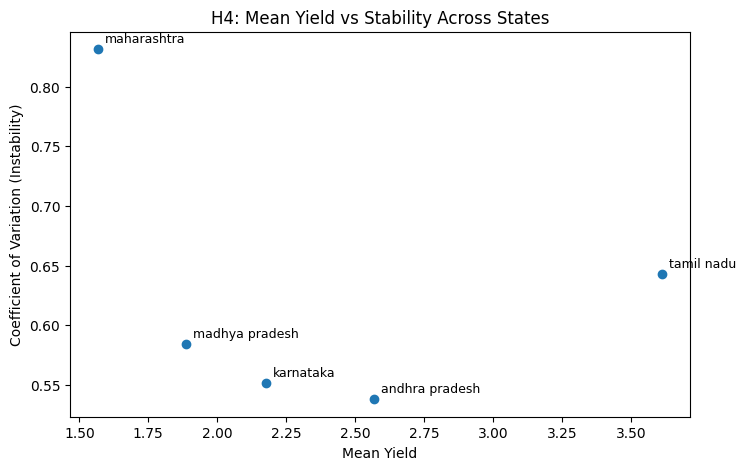

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(comparison["mean"], comparison["cv"])

for i, txt in enumerate(comparison["state"]):
    plt.annotate(
        txt,
        (comparison["mean"][i], comparison["cv"][i]),
        fontsize=9,
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Mean Yield")
plt.ylabel("Coefficient of Variation (Instability)")
plt.title("H4: Mean Yield vs Stability Across States")
comparison.to_csv("outputs/h4_indicator_test.csv", index=False)
plt.savefig("outputs/h4_plot.png")
plt.show()